## 1. Mount Google Drive

Google Drive is mounted to access the breast cancer dataset stored in Drive.

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

## 2. Extract the Dataset

The breast cancer image dataset is extracted from the ZIP file stored in Google Drive.

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/breast_cancer.zip"
extract_path = "/content/breast_cancer"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print(os.listdir(extract_path))

## 3. Check Dataset Distribution

The number of benign and malignant images in the training and test sets is checked to verify the dataset distribution.

In [38]:
import os

base_path = "/content/breast_cancer/Breast Cancer"

for split in ["train", "test"]:
    print(f"\n{split.upper()}")

    for class_name in ["breast_benign", "breast_malignant"]:
        folder = os.path.join(base_path, split, class_name)
        count = len(os.listdir(folder))
        print(class_name, ":", count)


TRAIN
breast_benign : 4000
breast_malignant : 4000

TEST
breast_benign : 1000
breast_malignant : 1000


## 4. Load the Dataset

The training and test images are loaded using TensorFlow's `image_dataset_from_directory` function. The images are resized to 128 × 128 pixels and organized into benign and malignant classes.

In [39]:
import tensorflow as tf

train_path = "/content/breast_cancer/Breast Cancer/train"
test_path = "/content/breast_cancer/Breast Cancer/test"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Class names:", train_dataset.class_names)

Found 8000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.
Class names: ['breast_benign', 'breast_malignant']


## 5. Build the Convolutional Neural Network (CNN)

A Convolutional Neural Network (CNN) is built to classify breast histopathology images into two classes: benign and malignant. The model uses convolutional layers to extract image features, pooling layers to reduce spatial dimensions, and fully connected layers for final classification.

In [40]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    # Normalize pixel values
    layers.Rescaling(1./255),

    # Convolutional layers
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    # Classification layers
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    # Binary classification
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Compile the CNN Model

The CNN model is compiled using the Adam optimizer, binary crossentropy loss function, and accuracy as the evaluation metric.

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

## 7. Split the Training Data into Training and Validation Sets

The training dataset is divided into 80% training data and 20% validation data. This allows the model to learn from the training images and be evaluated on unseen validation images during training.

In [42]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=123
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=123
)

print("Training images:", 6400)
print("Validation images:", 1600)

Found 8000 files belonging to 2 classes.
Using 6400 files for training.
Found 8000 files belonging to 2 classes.
Using 1600 files for validation.
Training images: 6400
Validation images: 1600


## 8. Train the CNN Model

The CNN model is trained for 10 epochs using the training dataset. The validation dataset is used during training to monitor the model's performance on unseen images.

In [43]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)




Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 270s 1s/step - accuracy: 0.8014 - loss: 0.4396 - val_accuracy: 0.8462 - val_loss: 0.3700
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 295s 1s/step - accuracy: 0.8777 - loss: 0.3134 - val_accuracy: 0.8969 - val_loss: 0.2540
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 261s 1s/step - accuracy: 0.8889 - loss: 0.2864 - val_accuracy: 0.9081 - val_loss: 0.2268
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 293s 1s/step - accuracy: 0.8978 - loss: 0.2570 - val_accuracy: 0.9000 - val_loss: 0.2524
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 280s 1s/step - accuracy: 0.9050 - loss: 0.2360 - val_accuracy: 0.9331 - val_loss: 0.1740
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 290s 1s/step - accuracy: 0.9156 - loss: 0.2179 - val_accuracy: 0.9369 - val_loss: 0.1722
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 294s 1s/step - accuracy: 0.9230 - loss: 0.1974 - val_accuracy: 0.9388 - val_loss: 0.1633
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 332s 1s/step - accuracy: 0.9247 - loss: 0.1904 - val_accu

## 9. Evaluate the Model on the Test Set

The trained CNN model is evaluated on the separate test dataset to measure its performance on unseen images. Test accuracy and test loss are used as the final evaluation metrics.

In [44]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 33s 514ms/step - accuracy: 0.9290 - loss: 0.1800
Test Loss: 0.18000027537345886
Test Accuracy: 0.9290000200271606


## 10. Confusion Matrix and Classification Report

A confusion matrix and classification report are used to evaluate the model's classification performance for benign and malignant breast histopathology images. Precision, recall, and F1-score are calculated for each class.

In [45]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend((predictions > 0.5).astype(int).flatten())

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["breast_benign", "breast_malignant"]
))

Confusion Matrix:
[[926  74]
 [ 68 932]]

Classification Report:
                  precision    recall  f1-score   support

   breast_benign       0.93      0.93      0.93      1000
breast_malignant       0.93      0.93      0.93      1000

        accuracy                           0.93      2000
       macro avg       0.93      0.93      0.93      2000
    weighted avg       0.93      0.93      0.93      2000



## 11. Training and Validation Performance

The training and validation accuracy and loss are plotted across the 10 training epochs to visualize the learning performance of the CNN model.

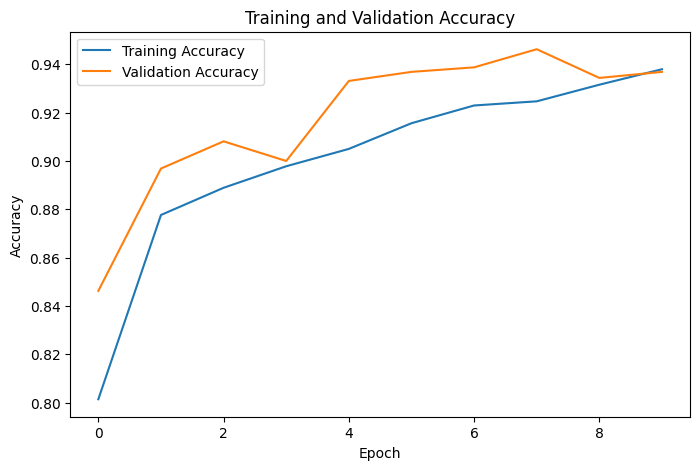

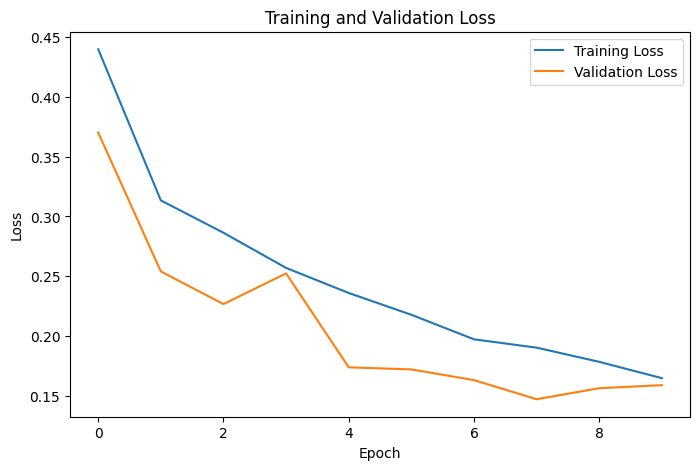

In [46]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

# Plot loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

## 12. Visualize the Confusion Matrix

The confusion matrix is visualized to clearly show the number of benign and malignant images that were correctly and incorrectly classified by the CNN model.

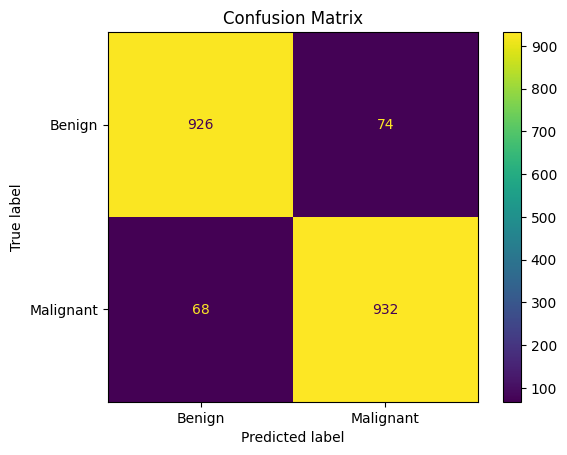

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
).plot()

plt.title("Confusion Matrix")
plt.show()

## 13. Test the Model on External Images

The trained CNN model is tested on four external histopathology images that were not part of the original training or test dataset. The model predicts whether each image is benign or malignant and provides its prediction confidence.

In [50]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

image_names = [
    "benign1.png",
    "benign2.png",
    "malignant1.png",
    "malignant2.png"
]

for image_name in image_names:

    image_path = "/content/drive/MyDrive/" + image_name

    # Load and resize image
    img = load_img(image_path, target_size=(128, 128))

    # Convert to array
    img_array = img_to_array(img)

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array, verbose=0)[0][0]

    # Interpret prediction
    if prediction >= 0.5:
        predicted_class = "Malignant"
        confidence = prediction
    else:
        predicted_class = "Benign"
        confidence = 1 - prediction

    print(image_name)
    print("Prediction:", predicted_class)
    print("Confidence:", f"{confidence * 100:.2f}%")
    print("-" * 40)

benign1.png
Prediction: Benign
Confidence: 54.84%
----------------------------------------
benign2.png
Prediction: Malignant
Confidence: 62.30%
----------------------------------------
malignant1.png
Prediction: Malignant
Confidence: 98.93%
----------------------------------------
malignant2.png
Prediction: Malignant
Confidence: 98.71%
----------------------------------------
